In [267]:
import scipy.io as sio
import numpy as np
import pandas as pd

# Load the .mat file
mat = sio.loadmat(r'E:\SHM_ML\data\trackedmodes\trackedmodes.mat')

# Unwrap the outer MATLAB struct layer
modes = mat['modes'][0, 0]

# Recursive function to reveal everything inside the struct
def print_struct(data, name="root", depth=0):
    indent = "  " * depth
    if hasattr(data, 'dtype') and data.dtype.names:
        print(f"{indent}{name} (struct):")
        for field in data.dtype.names:
            print_struct(data[field], field, depth + 1)
    elif hasattr(data, 'shape'):
        print(f"{indent}{name}: shape={data.shape}, first value={data.flat[0] if data.size > 0 else 'empty'}")
    else:
        print(f"{indent}{name}: {data}")

# Extract the three components we need
sdn = modes['sdn']        # timestamps — shape (11328, 1)
f = modes['f']            # natural frequencies — shape (11328, 14)
env = modes['env']        # environmental data — shape (11328, 11)
labels_env = modes['labels_env']  # names of environmental columns

# Build column names for frequencies
freq_cols = [f'f{i+1}' for i in range(f.shape[1])]

# Extract environmental column names from labels
env_cols = [str(labels_env[i, 0][0]) for i in range(labels_env.shape[0])]

# Build the DataFrame
df = pd.DataFrame(
    np.hstack([f, env]),
    columns=freq_cols + env_cols
)

# Add timestamp column at the front
df.insert(0, 'timestamp', sdn[:, 0])

print(df.shape)
print(df.head())

(11328, 26)
       timestamp  f1  f2  f3  f4  f5  f6  f7  f8  f9  ...  rhBD31A        tVL  \
0  737334.000000 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...      NaN  10.825000   
1  737334.041667 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...      NaN  10.241667   
2  737334.083333 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...      NaN  10.150000   
3  737334.125000 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...      NaN  10.166666   
4  737334.166667 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...      NaN   9.558333   

        rhVL         vpVL  grVL  drVL  dnrVL  raVL  wsVL  wdVL  
0  89.333336  1159.144738   NaN   NaN    NaN   NaN   NaN   NaN  
1  92.750000  1157.524605   NaN   NaN    NaN   NaN   NaN   NaN  
2  92.000000  1141.142430   NaN   NaN    NaN   NaN   NaN   NaN  
3  91.083336  1131.033604   NaN   NaN    NaN   NaN   NaN   NaN  
4  93.166664  1110.625906   NaN   NaN    NaN   NaN   NaN   NaN  

[5 rows x 26 columns]


In [268]:
def percentageNAN(dataframe):
    percentage = ((dataframe.isnull().sum())/ dataframe.shape[0])*100
    return percentage

In [269]:
# doing the column removing process in two ways 


# # dropping the columns that are above 50% empty 
empty  = percentageNAN(df)
# print(f'dropping {empty[empty > 50 ].index} columns')
to_drop = empty[empty > 50]
# print(to_drop)
# df.drop(columns=to_drop.index, axis = 1, inplace = True)
# df

# keeping the columns that are below 50% empty
to_keep = empty[empty <= 50]
print(f'keeping {to_keep.index} columns and removing {to_drop.index} columns')
df = df[to_keep.index]
df



keeping Index(['timestamp', 'f3', 'f4', 'f5', 'f6', 'f9', 'f10', 'f11', 'f12', 'f13',
       'tBD31A', 'rhBD31A', 'tVL', 'rhVL', 'vpVL', 'grVL', 'drVL', 'dnrVL',
       'raVL', 'wsVL', 'wdVL'],
      dtype='object') columns and removing Index(['f1', 'f2', 'f7', 'f8', 'f14'], dtype='object') columns


,timestamp,f3,f4,f5,f6,f9,f10,f11,f12,f13,...,rhBD31A,tVL,rhVL,vpVL,grVL,drVL,dnrVL,raVL,wsVL,wdVL
0,737334.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,10.825000,89.333336,1159.144738,NaN,NaN,NaN,NaN,NaN,NaN
1,737334.041667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,10.241667,92.750000,1157.524605,NaN,NaN,NaN,NaN,NaN,NaN
2,737334.083333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,10.150000,92.000000,1141.142430,NaN,NaN,NaN,NaN,NaN,NaN
3,737334.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,10.166666,91.083336,1131.033604,NaN,NaN,NaN,NaN,NaN,NaN
4,737334.166667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,9.558333,93.166664,1110.625906,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11323,737805.791667,1.888801,2.422909,2.555565,2.986277,4.078602,NaN,4.942893,5.440576,6.436793,...,83.304917,8.386441,83.342373,918.137648,0.0,0.0,0.0,0.0,1.96,200.08
11324,737805.833333,1.887610,2.423658,2.586921,2.982070,4.080208,NaN,4.940309,5.426145,6.398893,...,80.168936,7.545000,84.875000,882.549401,0.0,0.0,0.0,0.0,1.51,187.83
11325,737805.875000,1.886253,2.423930,2.581889,2.987133,4.078480,NaN,4.908271,5.432978,6.410531,...,82.076947,6.301667,89.455000,853.705976,0.0,0.0,0.0,0.0,1.07,199.95
11326,737805.916667,1.888356,2.423942,2.566954,2.987248,4.080275,NaN,4.940258,5.449368,6.425065,...,83.432317,5.583333,93.038333,845.126865,0.0,0.0,0.0,0.0,0.91,204.28


In [270]:
empty

timestamp     0.000000
f1           58.024364
f2           65.572034
f3            5.005297
f4           49.664548
f5           12.058616
f6            3.469280
f7           70.294845
f8           72.590042
f9            7.079802
f10          46.460099
f11          45.118291
f12          32.150424
f13          14.177260
f14          57.194562
tBD31A       12.014477
rhBD31A      12.694209
tVL           0.512006
rhVL          0.538489
vpVL          0.538489
grVL          8.324506
drVL          8.315678
dnrVL         8.315678
raVL          8.306850
wsVL         11.396540
wdVL         11.387712
dtype: float64

In [271]:
df['timestamp'] = pd.to_datetime(df['timestamp']- 719529 ,unit= 'D')



In [272]:
columns = df.columns.tolist()
print(columns)

for i in columns:
    print(df[i].dtype)

['timestamp', 'f3', 'f4', 'f5', 'f6', 'f9', 'f10', 'f11', 'f12', 'f13', 'tBD31A', 'rhBD31A', 'tVL', 'rhVL', 'vpVL', 'grVL', 'drVL', 'dnrVL', 'raVL', 'wsVL', 'wdVL']
datetime64[ns]
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64


In [273]:
df.duplicated().sum()

np.int64(0)

In [274]:
df = df.set_index('timestamp')


In [275]:
df.index

DatetimeIndex([          '2018-10-01 00:00:00',
               '2018-10-01 01:00:00.000006707',
               '2018-10-01 02:00:00.000003349',
                         '2018-10-01 03:00:00',
               '2018-10-01 04:00:00.000006707',
               '2018-10-01 05:00:00.000003349',
                         '2018-10-01 06:00:00',
               '2018-10-01 07:00:00.000006707',
               '2018-10-01 08:00:00.000003349',
                         '2018-10-01 09:00:00',
               ...
               '2020-01-15 13:59:59.999993292',
                         '2020-01-15 15:00:00',
               '2020-01-15 15:59:59.999996650',
               '2020-01-15 16:59:59.999993292',
                         '2020-01-15 18:00:00',
               '2020-01-15 18:59:59.999996650',
               '2020-01-15 19:59:59.999993292',
                         '2020-01-15 21:00:00',
               '2020-01-15 21:59:59.999996650',
               '2020-01-15 22:59:59.999993292'],
              dtype=

In [276]:
df.var()

f3              0.000169
f4              0.000212
f5              0.000650
f6              0.000758
f9              0.004871
f10             0.001324
f11             0.003942
f12             0.002375
f13             0.002631
tBD31A         44.215921
rhBD31A       212.845385
tVL            46.388722
rhVL          262.236285
vpVL       135360.199614
grVL        35896.117825
drVL         8396.615225
dnrVL       44891.016707
raVL            0.121690
wsVL            1.244133
wdVL         8963.195540
dtype: float64

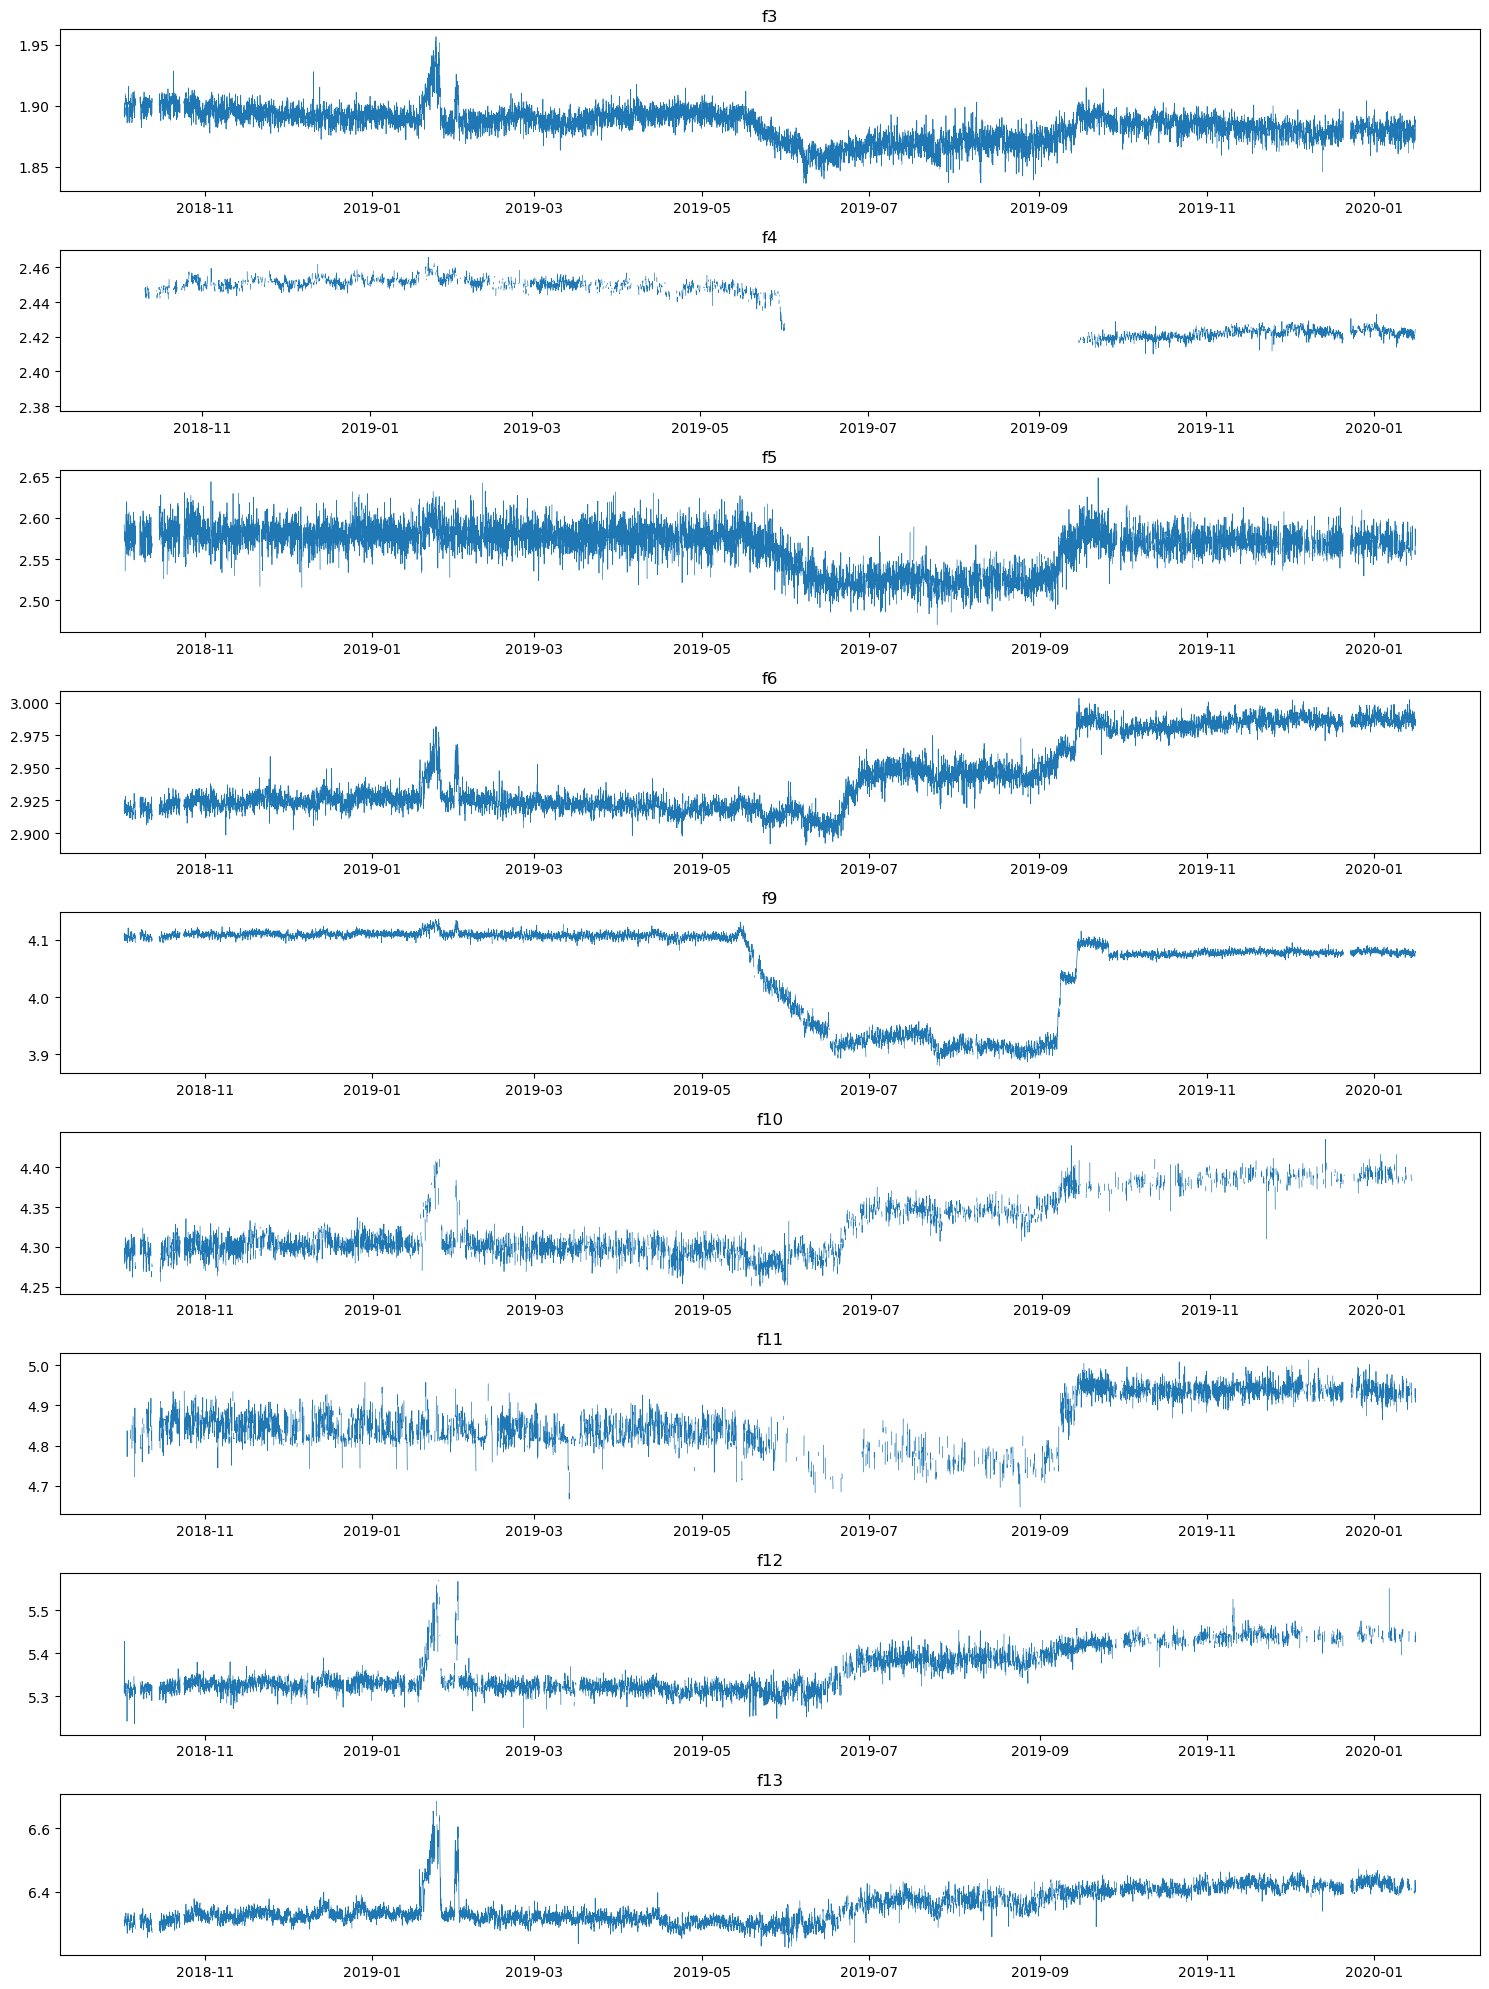

In [277]:
import matplotlib.pyplot as plt

freq_cols = ['f3', 'f4', 'f5', 'f6', 'f9', 'f10', 'f11', 'f12', 'f13']

fig, axes = plt.subplots(len(freq_cols), 1, figsize=(15, 20))

for i, col in enumerate(freq_cols):
    axes[i].plot(df.index, df[col], linewidth=0.5)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [278]:
# grouping the empty values in rows
for col in df.columns:
    gap = df[col].isnull()
    max_gap = gap.groupby((gap != gap.shift()).cumsum()).sum().max()
    print(f"{col}: {max_gap}")

f3: 65
f4: 2230
f5: 66
f6: 65
f9: 65
f10: 70
f11: 65
f12: 68
f13: 65
tBD31A: 1263
rhBD31A: 1156
tVL: 23
rhVL: 23
vpVL: 23
grVL: 216
drVL: 216
dnrVL: 216
raVL: 216
wsVL: 743
wdVL: 743


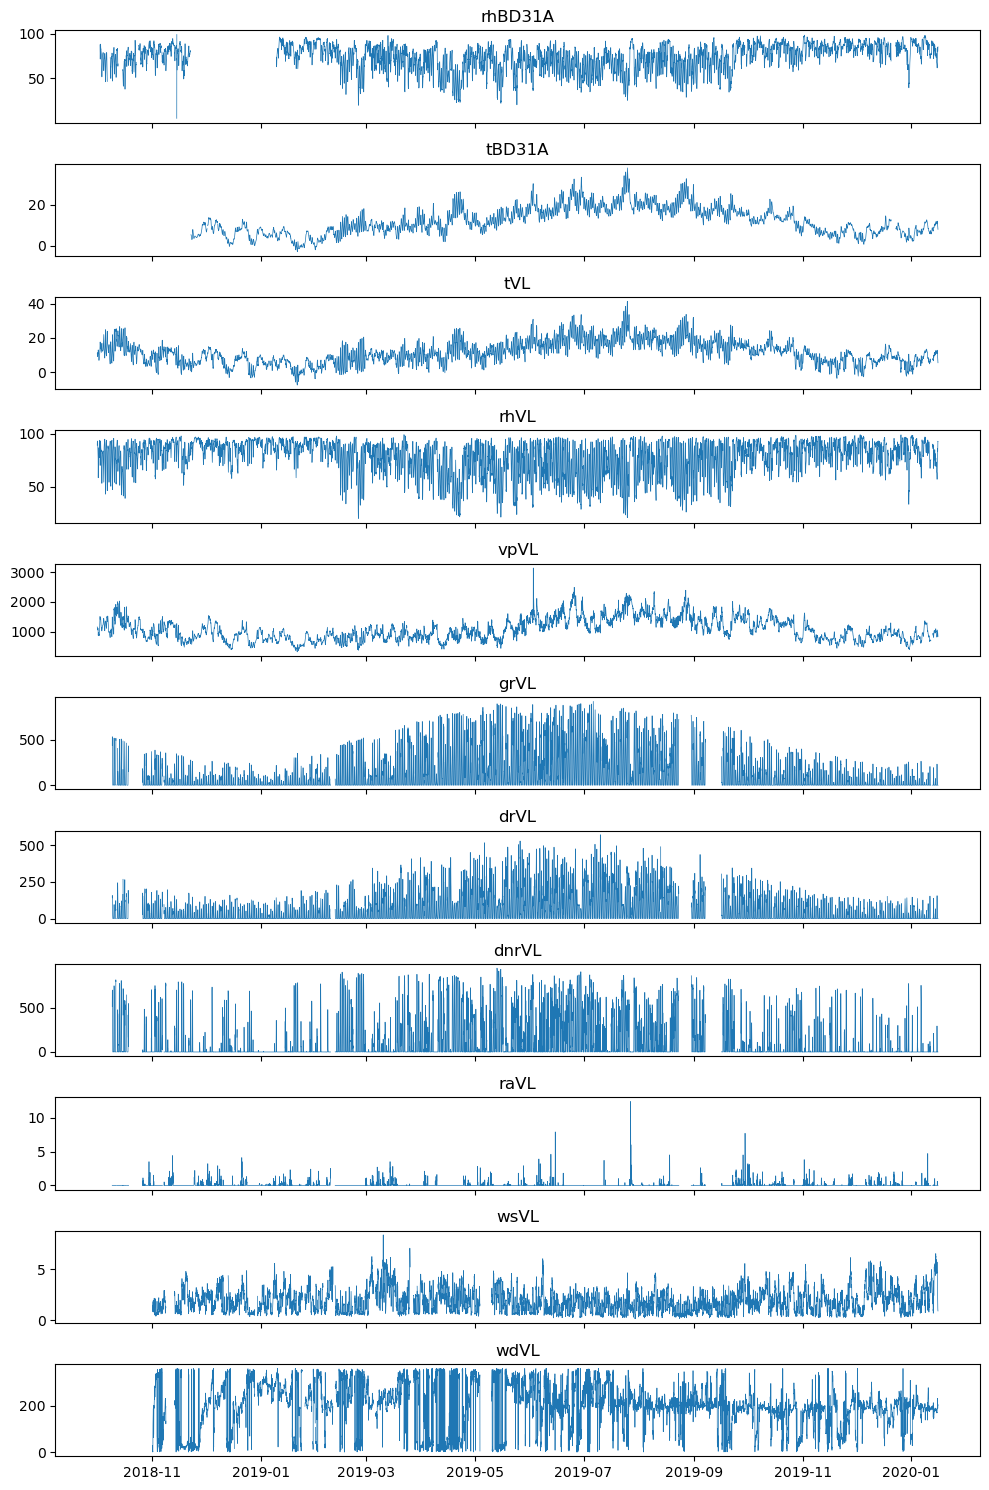

In [279]:
import matplotlib.pyplot as plt

env_col = ["rhBD31A", "tBD31A", "tVL", "rhVL", "vpVL", "grVL", "drVL", "dnrVL", "raVL", "wsVL", "wdVL"]

fig, axes = plt.subplots(len(env_col), 1, figsize=(10, 15), sharex=True)

for i, col in enumerate(env_col):
    axes[i].plot(df.index, df[col], linewidth=0.5)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [280]:
import requests
import pandas as pd

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 50.8798,
    "longitude": 4.7005,
    "start_date": "2018-10-01",
    "end_date": "2020-01-31",
    "hourly": "temperature_2m,relative_humidity_2m,vapour_pressure_deficit,rain,windspeed_10m,winddirection_10m",
    "timezone": "Europe/Brussels"
}

response = requests.get(url, params=params)
weather_data = response.json()
print(weather_data.keys())

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])


In [281]:
print(weather_data['hourly'])

{'time': ['2018-10-01T00:00', '2018-10-01T01:00', '2018-10-01T02:00', '2018-10-01T03:00', '2018-10-01T04:00', '2018-10-01T05:00', '2018-10-01T06:00', '2018-10-01T07:00', '2018-10-01T08:00', '2018-10-01T09:00', '2018-10-01T10:00', '2018-10-01T11:00', '2018-10-01T12:00', '2018-10-01T13:00', '2018-10-01T14:00', '2018-10-01T15:00', '2018-10-01T16:00', '2018-10-01T17:00', '2018-10-01T18:00', '2018-10-01T19:00', '2018-10-01T20:00', '2018-10-01T21:00', '2018-10-01T22:00', '2018-10-01T23:00', '2018-10-02T00:00', '2018-10-02T01:00', '2018-10-02T02:00', '2018-10-02T03:00', '2018-10-02T04:00', '2018-10-02T05:00', '2018-10-02T06:00', '2018-10-02T07:00', '2018-10-02T08:00', '2018-10-02T09:00', '2018-10-02T10:00', '2018-10-02T11:00', '2018-10-02T12:00', '2018-10-02T13:00', '2018-10-02T14:00', '2018-10-02T15:00', '2018-10-02T16:00', '2018-10-02T17:00', '2018-10-02T18:00', '2018-10-02T19:00', '2018-10-02T20:00', '2018-10-02T21:00', '2018-10-02T22:00', '2018-10-02T23:00', '2018-10-03T00:00', '2018-10-0

In [282]:
hourly_weather = pd.DataFrame(weather_data['hourly'])

In [283]:
hourly_weather

,time,temperature_2m,relative_humidity_2m,vapour_pressure_deficit,rain,windspeed_10m,winddirection_10m
0,2018-10-01T00:00,10.1,81,0.24,0.0,9.4,293
1,2018-10-01T01:00,10.0,85,0.18,0.1,10.3,295
2,2018-10-01T02:00,9.9,91,0.11,0.0,10.4,284
3,2018-10-01T03:00,9.8,89,0.13,0.3,11.6,296
4,2018-10-01T04:00,9.8,90,0.12,0.2,9.6,283
...,...,...,...,...,...,...,...
11707,2020-01-31T19:00,11.8,82,0.24,0.0,22.9,210
11708,2020-01-31T20:00,11.6,81,0.26,0.0,24.5,210
11709,2020-01-31T21:00,11.4,82,0.24,0.0,26.2,217
11710,2020-01-31T22:00,11.3,85,0.21,0.0,25.9,218


In [284]:
hourly_weather['time'] = pd.to_datetime(hourly_weather['time'])
hourly_weather.index = hourly_weather['time']
hourly_weather = hourly_weather.drop(columns=['time'])
hourly_weather

,temperature_2m,relative_humidity_2m,vapour_pressure_deficit,rain,windspeed_10m,winddirection_10m
time,,,,,,
2018-10-01 00:00:00,10.1,81,0.24,0.0,9.4,293
2018-10-01 01:00:00,10.0,85,0.18,0.1,10.3,295
2018-10-01 02:00:00,9.9,91,0.11,0.0,10.4,284
2018-10-01 03:00:00,9.8,89,0.13,0.3,11.6,296
2018-10-01 04:00:00,9.8,90,0.12,0.2,9.6,283
...,...,...,...,...,...,...
2020-01-31 19:00:00,11.8,82,0.24,0.0,22.9,210
2020-01-31 20:00:00,11.6,81,0.26,0.0,24.5,210
2020-01-31 21:00:00,11.4,82,0.24,0.0,26.2,217


In [285]:
df.index =  df.index.round('H')

C:\Users\forla\AppData\Local\Temp\ipykernel_1240\3483542924.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.index =  df.index.round('H')


In [286]:
hourly_weather.index


DatetimeIndex(['2018-10-01 00:00:00', '2018-10-01 01:00:00',
               '2018-10-01 02:00:00', '2018-10-01 03:00:00',
               '2018-10-01 04:00:00', '2018-10-01 05:00:00',
               '2018-10-01 06:00:00', '2018-10-01 07:00:00',
               '2018-10-01 08:00:00', '2018-10-01 09:00:00',
               ...
               '2020-01-31 14:00:00', '2020-01-31 15:00:00',
               '2020-01-31 16:00:00', '2020-01-31 17:00:00',
               '2020-01-31 18:00:00', '2020-01-31 19:00:00',
               '2020-01-31 20:00:00', '2020-01-31 21:00:00',
               '2020-01-31 22:00:00', '2020-01-31 23:00:00'],
              dtype='datetime64[ns]', name='time', length=11712, freq=None)

In [287]:
df.index.duplicated().sum()

np.int64(0)

In [288]:
print(hourly_weather.index.name)

time


In [289]:
hourly_weather.index.name = 'timestamp'
hourly_weather

,temperature_2m,relative_humidity_2m,vapour_pressure_deficit,rain,windspeed_10m,winddirection_10m
timestamp,,,,,,
2018-10-01 00:00:00,10.1,81,0.24,0.0,9.4,293
2018-10-01 01:00:00,10.0,85,0.18,0.1,10.3,295
2018-10-01 02:00:00,9.9,91,0.11,0.0,10.4,284
2018-10-01 03:00:00,9.8,89,0.13,0.3,11.6,296
2018-10-01 04:00:00,9.8,90,0.12,0.2,9.6,283
...,...,...,...,...,...,...
2020-01-31 19:00:00,11.8,82,0.24,0.0,22.9,210
2020-01-31 20:00:00,11.6,81,0.26,0.0,24.5,210
2020-01-31 21:00:00,11.4,82,0.24,0.0,26.2,217


In [290]:
df['tBD31A'] = df['tBD31A'].fillna(hourly_weather['temperature_2m'])


In [291]:
for i in df.columns:
    print(f"{i}: {df[i].isnull().sum()}")

f3: 567
f4: 5626
f5: 1366
f6: 393
f9: 802
f10: 5263
f11: 5111
f12: 3642
f13: 1606
tBD31A: 0
rhBD31A: 1438
tVL: 58
rhVL: 61
vpVL: 61
grVL: 943
drVL: 942
dnrVL: 942
raVL: 941
wsVL: 1291
wdVL: 1290


In [292]:
df['rhBD31A'] = df['rhBD31A'].fillna(hourly_weather['relative_humidity_2m'])
df['tVL'] = df['tVL'].fillna(hourly_weather['temperature_2m'])
df['rhVL'] = df['rhVL'].fillna(hourly_weather['relative_humidity_2m'])
df['vpVL'] = df['vpVL'].fillna(hourly_weather['vapour_pressure_deficit'])
df['raVL'] = df['raVL'].fillna(hourly_weather['rain'])
df['wsVL'] = df['wsVL'].fillna(hourly_weather['windspeed_10m'])

df['wdVL'] = df['wdVL'].fillna(hourly_weather['winddirection_10m'])

In [293]:
df[['rhBD31A', 'tVL', 'rhVL', 'vpVL', 'raVL', 'wsVL', 'wdVL']].isnull().sum()


rhBD31A    0
tVL        0
rhVL       0
vpVL       0
raVL       0
wsVL       0
wdVL       0
dtype: int64

In [294]:
cols_to_drop = ["f4", "grVL", "drVL", "dnrVL"]

df = df.drop(columns=cols_to_drop)

In [295]:
freq_cols.remove('f4')



In [296]:
print(freq_cols)


['f3', 'f5', 'f6', 'f9', 'f10', 'f11', 'f12', 'f13']


In [297]:
df[freq_cols] = df[freq_cols].ffill()
df[freq_cols].isnull().sum()
df

,f3,f5,f6,f9,f10,f11,f12,f13,tBD31A,rhBD31A,tVL,rhVL,vpVL,raVL,wsVL,wdVL
timestamp,,,,,,,,,,,,,,,,
2018-10-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.100000,81.000000,10.825000,89.333336,1159.144738,0.0,9.40,293.00
2018-10-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,85.000000,10.241667,92.750000,1157.524605,0.1,10.30,295.00
2018-10-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.900000,91.000000,10.150000,92.000000,1141.142430,0.0,10.40,284.00
2018-10-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.800000,89.000000,10.166666,91.083336,1131.033604,0.3,11.60,296.00
2018-10-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.800000,90.000000,9.558333,93.166664,1110.625906,0.2,9.60,283.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-15 19:00:00,1.888801,2.555565,2.986277,4.078602,4.386448,4.942893,5.440576,6.436793,9.641429,83.304917,8.386441,83.342373,918.137648,0.0,1.96,200.08
2020-01-15 20:00:00,1.887610,2.586921,2.982070,4.080208,4.386448,4.940309,5.426145,6.398893,9.143141,80.168936,7.545000,84.875000,882.549401,0.0,1.51,187.83
2020-01-15 21:00:00,1.886253,2.581889,2.987133,4.078480,4.386448,4.908271,5.432978,6.410531,8.795149,82.076947,6.301667,89.455000,853.705976,0.0,1.07,199.95


In [298]:
df[freq_cols].isnull().sum()

f3     37
f5     37
f6     37
f9     37
f10    37
f11    37
f12    37
f13    37
dtype: int64

In [306]:
df.iloc[36: 38, :]


,f3,f5,f6,f9,f10,f11,f12,f13,tBD31A,rhBD31A,tVL,rhVL,vpVL,raVL,wsVL,wdVL
timestamp,,,,,,,,,,,,,,,,
2018-10-02 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.6,88.000000,13.875000,91.000000,1443.026252,0.4,24.2,240.0
2018-10-02 13:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,12.9,87.570972,15.833333,84.083336,1512.691128,0.1,22.6,245.0


In [302]:
df.iloc[38, :]

f3            1.897737
f5            2.588505
f6            2.915454
f9            4.112165
f10           4.292376
f11           4.806421
f12           5.307689
f13           6.310908
tBD31A       12.900000
rhBD31A      83.012481
tVL          16.900000
rhVL         77.583336
vpVL       1493.826025
raVL          0.200000
wsVL         24.200000
wdVL        252.000000
Name: 2018-10-02 14:00:00, dtype: float64

In [311]:
df[freq_cols] = df[freq_cols].bfill()
df[freq_cols].isnull().sum()


f3     0
f5     0
f6     0
f9     0
f10    0
f11    0
f12    0
f13    0
dtype: int64

In [312]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11328 entries, 2018-10-01 00:00:00 to 2020-01-15 23:00:00
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   f3       11328 non-null  float64
 1   f5       11328 non-null  float64
 2   f6       11328 non-null  float64
 3   f9       11328 non-null  float64
 4   f10      11328 non-null  float64
 5   f11      11328 non-null  float64
 6   f12      11328 non-null  float64
 7   f13      11328 non-null  float64
 8   tBD31A   11328 non-null  float64
 9   rhBD31A  11328 non-null  float64
 10  tVL      11328 non-null  float64
 11  rhVL     11328 non-null  float64
 12  vpVL     11328 non-null  float64
 13  raVL     11328 non-null  float64
 14  wsVL     11328 non-null  float64
 15  wdVL     11328 non-null  float64
dtypes: float64(16)
memory usage: 1.7 MB


In [309]:
df[df['f3'].isnull()].index

DatetimeIndex(['2018-10-01 00:00:00', '2018-10-01 01:00:00',
               '2018-10-01 02:00:00', '2018-10-01 03:00:00',
               '2018-10-01 04:00:00', '2018-10-01 05:00:00',
               '2018-10-01 06:00:00', '2018-10-01 07:00:00',
               '2018-10-01 08:00:00', '2018-10-01 09:00:00',
               '2018-10-01 10:00:00', '2018-10-01 11:00:00',
               '2018-10-01 12:00:00', '2018-10-01 13:00:00',
               '2018-10-01 14:00:00', '2018-10-01 15:00:00',
               '2018-10-01 16:00:00', '2018-10-01 17:00:00',
               '2018-10-01 18:00:00', '2018-10-01 19:00:00',
               '2018-10-01 20:00:00', '2018-10-01 21:00:00',
               '2018-10-01 22:00:00', '2018-10-01 23:00:00',
               '2018-10-02 00:00:00', '2018-10-02 01:00:00',
               '2018-10-02 02:00:00', '2018-10-02 03:00:00',
               '2018-10-02 04:00:00', '2018-10-02 05:00:00',
               '2018-10-02 06:00:00', '2018-10-02 07:00:00',
               '2018-10-

In [313]:
df.to_csv('cleaned_data.csv')


OSError: [Errno 22] Invalid argument: 'cleaned_data.csv'

In [315]:
df.to_csv(r'E:\SHM_ML\data\cleaned\cleaned_data.csv')

In [316]:
print(df.columns)

Index(['f3', 'f5', 'f6', 'f9', 'f10', 'f11', 'f12', 'f13', 'tBD31A', 'rhBD31A',
       'tVL', 'rhVL', 'vpVL', 'raVL', 'wsVL', 'wdVL'],
      dtype='object')


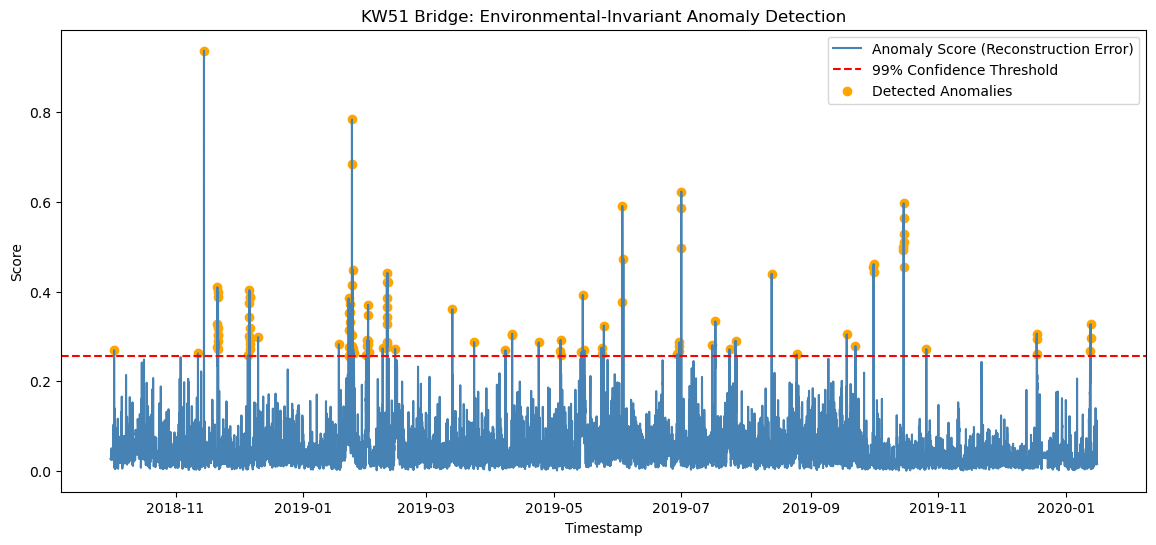

In [317]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Setup Column Groups
# 8 Frequencies + 8 Environmental/Weather features
freq_cols = ['f3', 'f5', 'f6', 'f9', 'f10', 'f11', 'f12', 'f13']
env_cols = ['tBD31A', 'rhBD31A', 'tVL', 'rhVL', 'vpVL', 'raVL', 'wsVL', 'wdVL']
all_features = freq_cols + env_cols

# Load your data
# df = pd.read_csv('your_file.csv')

# 2. Iterative Imputation (Handling the NaNs)
# Instead of dropping rows, we use correlations between sensors to fill gaps
imputer = IterativeImputer(max_iter=10, random_state=42)
df_imputed = pd.DataFrame(imputer.fit_transform(df[all_features]), columns=all_features)

# 3. Scaling
# Essential because frequency (Hz) and relative humidity (%) are on different scales
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_imputed)

# 4. PCA for Unsupervised Anomaly Detection
# We select enough components to explain 95% of the variance
# This captures the 'normal' relationship between environment and structural response
pca = PCA(n_components=0.95)
pca.fit(scaled_data)

# 5. Reconstruction and Anomaly Scoring
# Project data to the PCA space and back to original dimensions
reconstructed = pca.inverse_transform(pca.transform(scaled_data))

# Calculate the Squared Error (Residuals)
# Higher error = the physical relationship between weather and frequency is broken
anomaly_scores = np.mean(np.square(scaled_data - reconstructed), axis=1)

# 6. Thresholding
# Using the 99th percentile of your 15-month data as the 'normal' limit
threshold = np.percentile(anomaly_scores, 99)
anomalies = anomaly_scores > threshold

# 7. Visualization
plt.figure(figsize=(14, 6))
plt.plot(df.index, anomaly_scores, label='Anomaly Score (Reconstruction Error)', color='steelblue')
plt.axhline(y=threshold, color='red', linestyle='--', label='99% Confidence Threshold')
plt.scatter(df.index[anomalies], anomaly_scores[anomalies], color='orange', label='Detected Anomalies')
plt.title('KW51 Bridge: Environmental-Invariant Anomaly Detection')
plt.xlabel('Timestamp')
plt.ylabel('Score')
plt.legend()
plt.show()

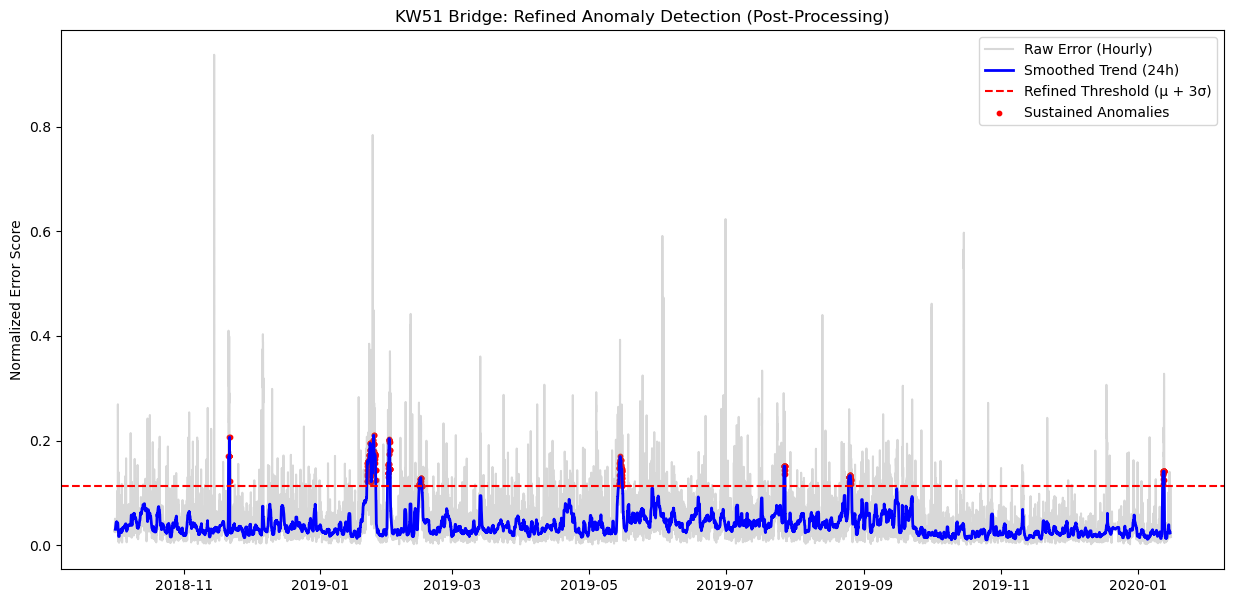

In [318]:
# 1. Smooth the Anomaly Scores
# A 24-hour window helps filter out transient hourly noise
window_size = 24 
df_imputed['smooth_score'] = pd.Series(anomaly_scores).rolling(window=window_size, center=True).median()

# 2. Dynamic Thresholding (Optional but Recommended)
# Instead of a flat line, use Mean + 3*Std Dev
refined_threshold = df_imputed['smooth_score'].mean() + (3 * df_imputed['smooth_score'].std())

# 3. Enhanced Visualization
plt.figure(figsize=(15, 7))
plt.plot(df.index, anomaly_scores, alpha=0.3, label='Raw Error (Hourly)', color='gray')
plt.plot(df.index, df_imputed['smooth_score'], label='Smoothed Trend (24h)', color='blue', linewidth=2)
plt.axhline(y=refined_threshold, color='red', linestyle='--', label='Refined Threshold (μ + 3σ)')

# Highlighting only sustained anomalies
sustained_anomalies = df_imputed['smooth_score'] > refined_threshold
plt.scatter(df.index[sustained_anomalies], df_imputed.loc[sustained_anomalies, 'smooth_score'], 
            color='red', s=10, label='Sustained Anomalies')

plt.title('KW51 Bridge: Refined Anomaly Detection (Post-Processing)')
plt.ylabel('Normalized Error Score')
plt.legend()
plt.show()

In [319]:
# 1. Create a "Hinge" Feature for the freezing point
# This helps the model understand that behavior changes at 0 degrees
df_imputed['temp_frozen'] = df_imputed['tBD31A'].apply(lambda x: min(0, x))

# 2. Update your feature list
refined_features = freq_cols + env_cols + ['temp_frozen']

# 3. Re-run PCA with the Non-Linear "Hinge"
scaled_data_v2 = scaler.fit_transform(df_imputed[refined_features])
pca_v2 = PCA(n_components=0.95)
pca_v2.fit(scaled_data_v2)

# 4. Calculate new Anomaly Scores
reconstructed_v2 = pca_v2.inverse_transform(pca_v2.transform(scaled_data_v2))
# Only calculate error on the Frequency columns (the output we care about)
freq_indices = [refined_features.index(f) for f in freq_cols]
anomaly_scores_v2 = np.mean(np.square(scaled_data_v2[:, freq_indices] - reconstructed_v2[:, freq_indices]), axis=1)

# 5. Smooth and Plot
df_imputed['score_v2_smooth'] = pd.Series(anomaly_scores_v2).rolling(window=24, center=True).median()

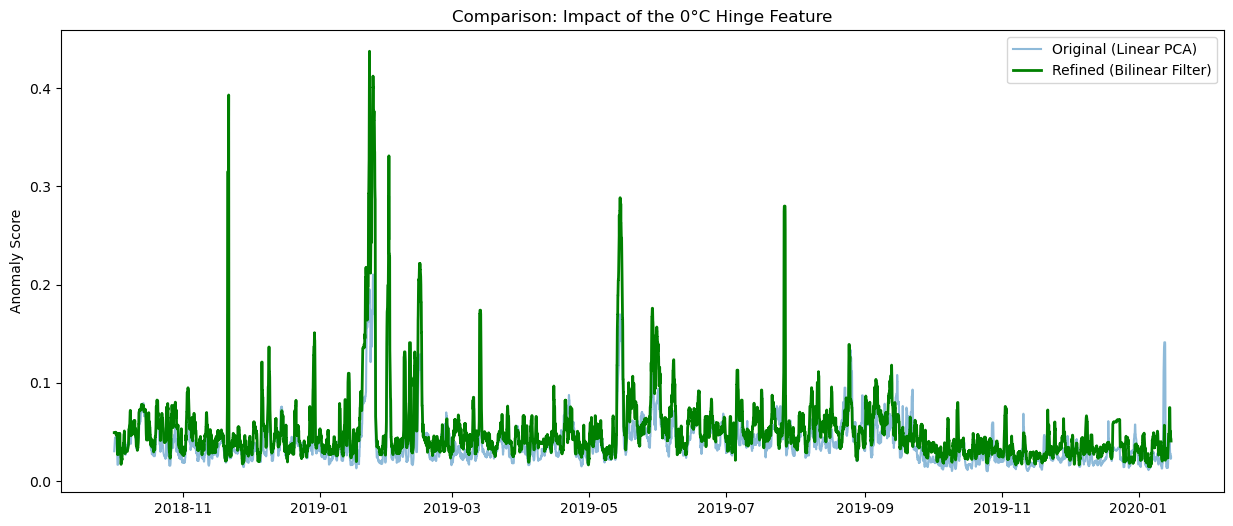

In [320]:
plt.figure(figsize=(15, 6))

# Plotting the old vs new scores
plt.plot(df.index, df_imputed['smooth_score'], label='Original (Linear PCA)', alpha=0.5)
plt.plot(df.index, df_imputed['score_v2_smooth'], label='Refined (Bilinear Filter)', color='green', linewidth=2)

plt.title('Comparison: Impact of the 0°C Hinge Feature')
plt.ylabel('Anomaly Score')
plt.legend()
plt.show()

In [321]:
# Calculate a Central Limit (Baseline) from the first 3 months (assuming healthy)
baseline_mean = df_imputed['score_v2_smooth'].iloc[:2160].mean()
baseline_std = df_imputed['score_v2_smooth'].iloc[:2160].std()

# Upper Control Limit (UCL)
ucl = baseline_mean + (3 * baseline_std)

# Identify "Alert" periods (where score stays above UCL for > 12 hours)
df_imputed['alert'] = (df_imputed['score_v2_smooth'] > ucl).rolling(window=12).sum() == 12

print(f"Total Hours of Structural Alerts: {df_imputed['alert'].sum()}")

Total Hours of Structural Alerts: 239


In [322]:
correlation = df_imputed['score_v2_smooth'].corr(df_imputed['tBD31A'])
print(f"Residual Correlation with Temperature: {correlation:.4f}")

Residual Correlation with Temperature: 0.0002


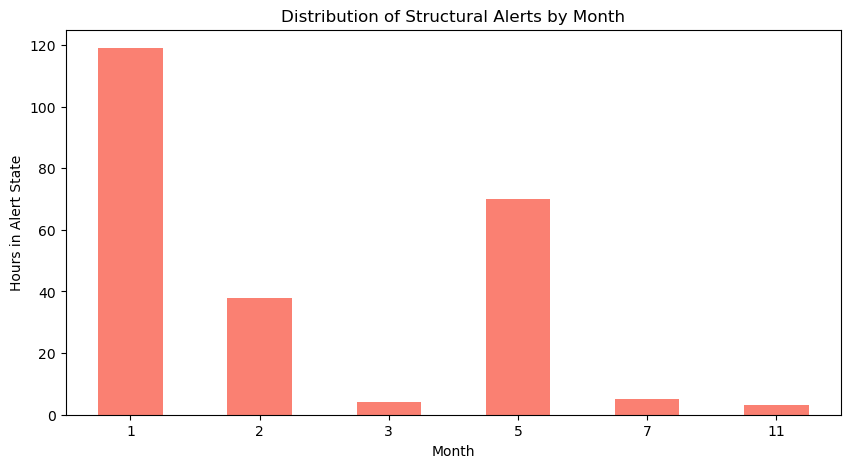

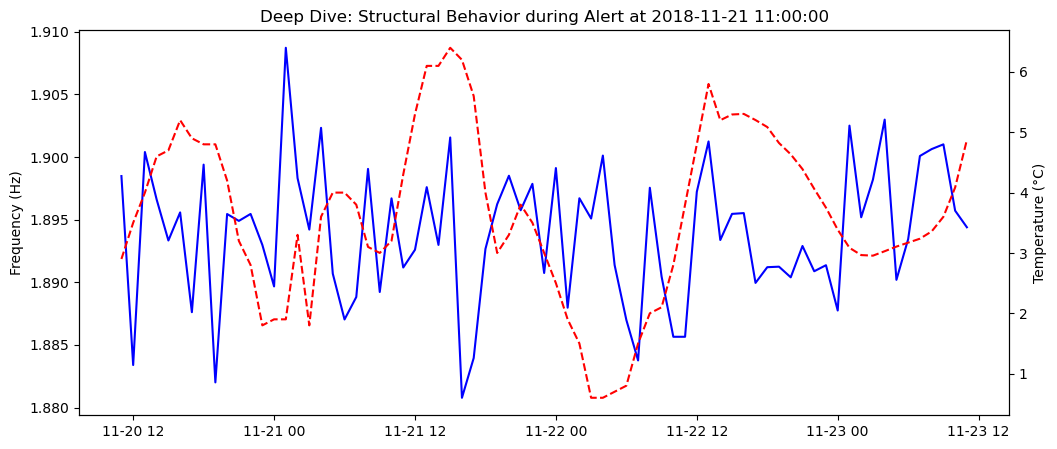

In [323]:
# 1. Create a summary of alerts by month
df_imputed['month'] = df.index.month
alert_summary = df_imputed[df_imputed['alert'] == True].groupby('month').size()

# 2. Visualize where the alerts live
plt.figure(figsize=(10, 5))
alert_summary.plot(kind='bar', color='salmon')
plt.title('Distribution of Structural Alerts by Month')
plt.xlabel('Month')
plt.ylabel('Hours in Alert State')
plt.xticks(rotation=0)
plt.show()

# 3. Physical Sanity Check: Plot Frequencies during an Alert
# Pick the first date where an alert happened
alert_dates = df.index[df_imputed['alert'] == True]
if len(alert_dates) > 0:
    first_event = alert_dates[0]
    # Plot a 3-day window around the first alert
    window = df.loc[first_event - pd.Timedelta(days=1) : first_event + pd.Timedelta(days=2)]
    
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()
    
    ax1.plot(window.index, window['f3'], color='blue', label='Frequency (f3)')
    ax2.plot(window.index, window['tBD31A'], color='red', linestyle='--', label='Temp')
    
    plt.title(f'Deep Dive: Structural Behavior during Alert at {first_event}')
    ax1.set_ylabel('Frequency (Hz)')
    ax2.set_ylabel('Temperature (°C)')
    plt.show()